In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

from google.colab import drive

import warnings
import math
import numbers

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# Load & Prepare the PhysioNet 2012 data

In [ ]:
# mount Google Drive
drive.mount('/content/drive')

# paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
set_c_directory = f"{google_drive_folder}/set-c"
outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"
outcomes_c_file = f"{set_c_directory}/Outcomes-c.txt"

print("Set A Directory:", set_a_directory)
print("Set B Directory:", set_b_directory)
print("Set C Directory:", set_c_directory)
print("Outcomes A File:", outcomes_a_file)
print("Outcomes B File:", outcomes_b_file)
print("Outcomes C File:", outcomes_c_file)

Mounted at /content/drive
Set A Directory: /content/drive/MyDrive/physionet2012//set-a
Set B Directory: /content/drive/MyDrive/physionet2012//set-b
Set C Directory: /content/drive/MyDrive/physionet2012//set-c
Outcomes A File: /content/drive/MyDrive/physionet2012//set-a/Outcomes-a.txt
Outcomes B File: /content/drive/MyDrive/physionet2012//set-b/Outcomes-b.txt
Outcomes C File: /content/drive/MyDrive/physionet2012//set-c/Outcomes-c.txt


In [ ]:

outcomes_a = pd.read_csv(outcomes_a_file)
outcomes_b = pd.read_csv(outcomes_b_file)
outcomes_c = pd.read_csv(outcomes_c_file)

# Add 'set' column and combine
outcomes_a['set'] = 'a'
outcomes_b['set'] = 'b'
outcomes_c['set'] = 'c'

combined_outcomes = pd.concat([outcomes_a, outcomes_b, outcomes_c], ignore_index=True)

# Filter out records with In-hospital_death == -1
filtered_outcomes = combined_outcomes[combined_outcomes['In-hospital_death'] != -1].reset_index(drop=True)
print("Number of records after filtering:", len(filtered_outcomes))

Number of records after filtering: 12000


In [ ]:
import pandas as pd
import numpy as np

def parse_patient_file(file_path):
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return pd.DataFrame(columns=['Time']), {}

    static_features = {}
    dynamic_data = {}

    for index, row in df.iterrows():
        time_str = row['Time']
        param = row['Parameter']
        value = row['Value']

        try:
            if ':' in str(time_str):
                hours, minutes = map(int, time_str.split(':'))
                total_minutes = float(hours * 60 + minutes)
            else:
                total_minutes = float(time_str)
        except (ValueError, TypeError):
             total_minutes = 0.0

        try:
            numeric_value = float(value)
        except (ValueError, TypeError):
            numeric_value = np.nan

        if total_minutes == 0:
            static_features[param] = numeric_value
        else:
            if total_minutes not in dynamic_data:
                dynamic_data[total_minutes] = {}
            dynamic_data[total_minutes][param] = numeric_value

    if dynamic_data:
        dynamic_df = pd.DataFrame.from_dict(dynamic_data, orient='index')
        dynamic_df.index.name = 'Time'
        dynamic_df = dynamic_df.sort_index().reset_index()
    else:
        dynamic_df = pd.DataFrame(columns=['Time'])

    return dynamic_df, static_features

In [ ]:
def load_all_patients(set_path, outcomes_df):
    """
    Loads all patient data from a given set directory.
    Returns:
        - patient_data: List of tuples, where each tuple is (dynamic_df, static_features_dict).
        - labels: List of corresponding labels (In-hospital_death).
    """
    patient_data = []
    labels = []
    set_name = os.path.basename(set_path)

    patient_files = [f for f in os.listdir(set_path)
                     if f.endswith('.txt') and not f.startswith('Outcomes')]

    for pf in tqdm(patient_files, desc=f"Loading {set_name}"):
        try:
            record_id_str = pf.split('.')[0]
            record_id = int(record_id_str)
        except ValueError:
            print(f"Warning: Could not parse RecordID from filename '{pf}'. Skipping.")
            continue

        file_path = os.path.join(set_path, pf)
        dynamic_df, static_dict = parse_patient_file(file_path)

        dynamic_df['RecordID'] = record_id
        static_dict['RecordID'] = record_id

        outcome_row = outcomes_df[outcomes_df['RecordID'] == record_id]
        if outcome_row.empty:
            print(f"Warning: No outcome found for RecordID {record_id}. Skipping.")
            continue

        if len(outcome_row) > 1:
             print(f"Warning: Multiple outcome entries found for RecordID {record_id}. Using first.")
             outcome_row = outcome_row.iloc[0:1]


        label = outcome_row['In-hospital_death'].values[0]

        if label not in [0, 1]:
             print(f"Warning: Invalid label '{label}' for RecordID {record_id} after filtering. Skipping.")
             continue


        if not dynamic_df.empty or static_dict:
             patient_data.append((dynamic_df, static_dict))
             labels.append(label)
        else:
             print(f"Warning: No data found for RecordID {record_id} in {file_path}. Skipping.")


    return patient_data, labels

In [ ]:
train_data, train_labels = load_all_patients(set_a_directory,
                                            filtered_outcomes[filtered_outcomes['set']=='a'])
val_data, val_labels = load_all_patients(set_b_directory,
                                        filtered_outcomes[filtered_outcomes['set']=='b'])

test_data, test_labels = load_all_patients( set_c_directory,
                                           filtered_outcomes[filtered_outcomes['set']=='c'])


print("\nNumber of train samples:", len(train_data))
print("Number of val samples:", len(val_data))
print("Number of test samples:", len(test_data))

Loading set-c: 100%|██████████| 4000/4000 [02:43<00:00, 24.48it/s]


Number of train samples: 4000
Number of val samples: 4000
Number of test samples: 4000


# Create Sequences (X, Mask, Delta) + Labels

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings

def create_sequences(patient_data_tuples, labels, static_feats, dynamic_feats, max_time=201):
    """
    Convert patient data (dynamic DFs and static dicts) into (X, Mask, Delta) plus label.
    Ensures all static and dynamic features are included consistently.
    Pads sequences to max_time steps. Uses a safe delta calculation.

    Args:
        patient_data_tuples: List of tuples [(dynamic_df, static_dict), ...].
        labels: List of labels.
        static_feats: List of static feature names.
        dynamic_feats: List of dynamic feature names.
        max_time: Maximum sequence length.

    Returns:
        Dict of np.arrays: {'X', 'mask', 'delta', 'y'}.
        Dimensions: (N, max_time, num_all_features) for X, mask, delta. (N,) for y.
    """

    all_feats = static_feats + dynamic_feats
    num_static = len(static_feats)
    num_dynamic = len(dynamic_feats)
    num_all_feats = len(all_feats)
    feature_indices = {feat: idx for idx, feat in enumerate(all_feats)}

    static_indices = [feature_indices[feat] for feat in static_feats]
    dynamic_indices = [feature_indices[feat] for feat in dynamic_feats]

    print(f"processing sequences with {num_static} static and {num_dynamic} dynamic features (total: {num_all_feats}).")

    x_list, m_list, d_list, y_list = [], [], [], []


    for i, (dynamic_df, static_dict) in enumerate(tqdm(patient_data_tuples, desc='building sequences')):
        label = labels[i]


        dynamic_df = dynamic_df.sort_values('Time').reset_index(drop=True)
        times = dynamic_df['Time'].values.astype(float)


        t_dynamic = len(times)


        if t_dynamic == 0:
           if not static_dict:
               record_id = "n/a"
               if isinstance(static_dict, dict): record_id = static_dict.get('RecordID', 'n/a')
               if isinstance(dynamic_df, pd.DataFrame) and 'RecordID' in dynamic_df.columns and not dynamic_df.empty: record_id = dynamic_df['RecordID'].iloc[0]
               warnings.warn(f"patient {i} (recordid: {record_id}) has no dynamic or static data. skipping.")
               continue
           else:
               t = 1
               times = np.array([0.0])
        else:
            t = t_dynamic


        patient_x = np.full((t, num_all_feats), np.nan, dtype=np.float32)
        patient_m = np.zeros((t, num_all_feats), dtype=np.float32)
        patient_d = np.zeros((t, num_all_feats), dtype=np.float32)


        for feat_name, static_col_idx in zip(static_feats, static_indices):
            if feat_name in static_dict and not pd.isna(static_dict[feat_name]):
                patient_x[:, static_col_idx] = static_dict[feat_name]
                patient_m[:, static_col_idx] = 1.0



        for t_step in range(t):
            current_time = times[t_step]


            if t_step == 0:
                time_diff = current_time
            else:
                time_diff = current_time - times[t_step-1]


            time_diff = max(0.0, time_diff)


            patient_d[t_step, dynamic_indices] = time_diff


            if not dynamic_df.empty and t_step < t_dynamic:
                row_data = dynamic_df.iloc[t_step]
                for feat_name, dynamic_col_idx in zip(dynamic_feats, dynamic_indices):

                     if feat_name in dynamic_df.columns and not pd.isna(row_data[feat_name]):
                          patient_x[t_step, dynamic_col_idx] = row_data[feat_name]
                          patient_m[t_step, dynamic_col_idx] = 1.0



        patient_x_filled = np.nan_to_num(patient_x, nan=0.0, posinf=0.0, neginf=0.0)


        seq_len = min(t, max_time)


        x_padded = np.zeros((max_time, num_all_feats), dtype=np.float32)
        m_padded = np.zeros((max_time, num_all_feats), dtype=np.float32)
        d_padded = np.zeros((max_time, num_all_feats), dtype=np.float32)


        x_padded[:seq_len] = patient_x_filled[:seq_len]
        m_padded[:seq_len] = patient_m[:seq_len]
        d_padded[:seq_len] = patient_d[:seq_len]


        x_list.append(x_padded)
        m_list.append(m_padded)
        d_list.append(d_padded)
        y_list.append(label)



    if not x_list:
         warnings.warn("no valid sequences were generated. returning empty arrays.")
         empty_shape = (0, max_time, num_all_feats)
         return {
             'x': np.zeros(empty_shape, dtype=np.float32),
             'mask': np.zeros(empty_shape, dtype=np.float32),
             'delta': np.zeros(empty_shape, dtype=np.float32),
             'y': np.array([], dtype=np.float32)
         }

    x_array = np.array(x_list, dtype=np.float32)
    m_array = np.array(m_list, dtype=np.float32)
    d_array = np.array(d_list, dtype=np.float32)
    y_array = np.array(y_list, dtype=np.float32)


    if m_array.size > 0:
        missing_feature_check = np.sum(m_array, axis=(0, 1))
        all_missing_indices = np.where(missing_feature_check == 0)[0]
        if len(all_missing_indices) > 0:
             all_missing_features = [all_feats[i] for i in all_missing_indices]
             warnings.warn(f"the following features are missing from all records: {all_missing_features}. "
                           "they will have zero masks and deltas, and imputed x values (0.0). ")

    return {
        'x': x_array,
        'mask': m_array,
        'delta': d_array,
        'y': y_array
    }

In [ ]:
# identify static features (Physionet 2012)
static_features = ['Age', 'Gender', 'Height', 'ICUType', 'Weight']

# dynamic features are all columns except 'Time' and static features
dynamic_features = ['Albumin', 'ALP', 'ALT', 'AST', 'Bilirubin', 'BUN', 'Cholesterol',
                    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
                    'HR', 'K', 'Lactate', 'Mg', 'MAP', 'MechVent', 'Na', 'NIDiasABP',
                    'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH', 'Platelets', 'RespRate',
                    'SaO2', 'SysABP', 'Temp', 'TropI', 'TropT', 'Urine', 'WBC'
                   ]

train_seqs = create_sequences(train_data, train_labels, static_features, dynamic_features, max_time=201)
val_seqs   = create_sequences(val_data,   val_labels,   static_features, dynamic_features, max_time=201)
test_seqs  = create_sequences(test_data,  test_labels,  static_features, dynamic_features, max_time=201)

print("Train X shape:", train_seqs['X'].shape)
print("Val   X shape:", val_seqs['X'].shape)
print("Unique train labels:", np.unique(train_seqs['y']))
print("Unique val   labels:", np.unique(val_seqs['y']))
print("Test   X shape:", test_seqs['X'].shape)
print("Unique test   labels:", np.unique(test_seqs['y']))

Processing sequences with 5 static and 36 dynamic features (Total: 41).


Building sequences: 100%|██████████| 4000/4000 [00:56<00:00, 70.19it/s]
<ipython-input-7-5e5ec0392178>:155: UserWarning: The following features are missing from ALL records: ['TropI', 'TropT']. They will have zero masks and deltas, and imputed X values (0.0). Consider removing them from static_feats/dynamic_feats lists.
  warnings.warn(f"The following features are missing from ALL records: {all_missing_features}. "


Processing sequences with 5 static and 36 dynamic features (Total: 41).


Building sequences: 100%|██████████| 4000/4000 [00:56<00:00, 71.27it/s]


Processing sequences with 5 static and 36 dynamic features (Total: 41).


Building sequences: 100%|██████████| 4000/4000 [00:56<00:00, 70.80it/s]


Train X shape: (4000, 201, 41)
Val   X shape: (4000, 201, 41)
Unique train labels: [0. 1.]
Unique val   labels: [0. 1.]
Test   X shape: (4000, 201, 41)
Unique test   labels: [0. 1.]


# Define Manual GRU-D Model (Vectorized for Batches)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GRUD(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size=1,
        x_mean=None,
        dropout=0.0,
        dropout_type='mloss',
    ):
        """
        input_size: Dimensionality of the features (D).
        hidden_size: Dimensionality of the hidden state (H).
        output_size: Usually 1 for binary classification.
        x_mean: If given, must be a 1D tensor of shape (D,) containing the mean of each feature.
        """
        super(GRUD, self).__init__()
        self.input_size = input_size   # number of features (D)
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout = dropout
        self.dropout_type = dropout_type

        # If no mean is provided, default to zeros
        if x_mean is None:
            self.register_buffer("x_mean", torch.zeros(input_size))
        else:
            self.register_buffer("x_mean", torch.tensor(x_mean, dtype=torch.float32))

        # --------------------------
        # Define the "decay" linear layers
        #    W_dg_x:  (D -> D),   W_dg_h: (D -> H).
        #    This is how we compute gamma_x(t) and gamma_h(t) from Delta_t.
        # --------------------------
        self.W_dg_x = nn.Linear(input_size, input_size, bias=True)  # maps delta_t (D-dim) -> gamma_x (D-dim)
        self.W_dg_h = nn.Linear(input_size, hidden_size, bias=True) # maps delta_t (D-dim) -> gamma_h (H-dim)

        # --------------------------
        # GRU gates: z, r, h_tilde
        #    We keep the "m_t" gate terms as in Che et al.
        # --------------------------
        self.w_xz = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hz = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mz = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_z  = nn.Parameter(torch.Tensor(hidden_size))

        self.w_xr = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hr = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mr = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_r  = nn.Parameter(torch.Tensor(hidden_size))

        self.w_xh = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mh = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_h  = nn.Parameter(torch.Tensor(hidden_size))

        # Final classifier layer
        self.w_hy = nn.Parameter(torch.Tensor(hidden_size, output_size))
        self.b_y  = nn.Parameter(torch.Tensor(output_size))

        self.reset_parameters()

    def reset_parameters(self):
        # Simple uniform initialization
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for p in self.parameters():
            nn.init.uniform_(p, -stdv, stdv)

    def forward(self, X, M, Delta):
        """
        X:     (batch_size, T, D)   - raw features
        M:     (batch_size, T, D)   - mask (1 if observed, 0 if missing)
        Delta: (batch_size, T, D)   - time since last observation for each feature
        Returns:
            (batch_size,) or (batch_size, 1) if output_size=1
        """
        batch_size, T, D = X.size()
        H = self.hidden_size

        # Initialize hidden state and "previous" imputed x
        h = X.new_zeros(batch_size, H)      # shape (batch_size, H)
        x_hat = X.new_zeros(batch_size, D)  # shape (batch_size, D)

        # For dropout
        dropout_layer = nn.Dropout(self.dropout)

        for t in range(T):
            x_t = X[:, t, :]      # shape (batch_size, D)
            m_t = M[:, t, :]      # shape (batch_size, D)
            d_t = Delta[:, t, :]  # shape (batch_size, D)

            # ----------------------------------------
            # Compute gamma_x(t) and gamma_h(t)
            #    gamma_x: (batch_size, D)
            #    gamma_h: (batch_size, H)
            # ----------------------------------------
            gamma_x_t = torch.exp(-F.relu(self.W_dg_x(d_t)))
            gamma_h_t = torch.exp(-F.relu(self.W_dg_h(d_t)))

            # ----------------------------------------
            # Update x_hat(t)
            #    x_hat(t) = m_t * x_t  + (1-m_t)* [ gamma_x_t*x_hat(t-1) + (1-gamma_x_t)* x_mean ]
            # ----------------------------------------
            x_hat = m_t * x_t + (1 - m_t) * (gamma_x_t * x_hat + (1 - gamma_x_t) * self.x_mean)

            # ----------------------------------------
            # Decay hidden state: h(t-1) -> gamma_h(t) * h(t-1)
            # ----------------------------------------
            h = gamma_h_t * h

            # ----------------------------------------
            # Standard GRU gating on the imputed input x_hat(t)
            # ----------------------------------------
            # z gate
            z = torch.sigmoid(
                x_hat @ self.w_xz + h @ self.w_hz + m_t @ self.w_mz + self.b_z
            )

            # r gate
            r = torch.sigmoid(
                x_hat @ self.w_xr + h @ self.w_hr + m_t @ self.w_mr + self.b_r
            )

            # h tilde
            h_tilde = torch.tanh(
                x_hat @ self.w_xh + (r * h) @ self.w_hh + m_t @ self.w_mh + self.b_h
            )

            if self.dropout > 0:
                if self.dropout_type == 'mloss':
                    h_tilde = dropout_layer(h_tilde)
                elif self.dropout_type == 'Gal':
                    h = dropout_layer(h)

            # GRU update
            h = (1 - z) * h + z * h_tilde

        # Final output
        y_out = h @ self.w_hy + self.b_y  # (batch_size, output_size)
        y_out = torch.sigmoid(y_out)
        return y_out.squeeze(-1)  # shape (batch_size,) if output_size=1


# Create PyTorch Dataset & DataLoaders

In [ ]:
class PhysioNetDataset(Dataset):
    def __init__(self, seqs_dict):
        # seqs_dict has 'X', 'mask', 'delta', 'y'
        self.X = seqs_dict['X']  # shape (N, T, D)
        self.M = seqs_dict['mask']
        self.D = seqs_dict['delta']
        self.y = seqs_dict['y']

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return (
            self.X[idx],  # shape (T, D)
            self.M[idx],
            self.D[idx],
            self.y[idx],
        )

# Create dataset objects
train_dataset = PhysioNetDataset(train_seqs)
val_dataset   = PhysioNetDataset(val_seqs)
test_dataset = PhysioNetDataset(test_seqs)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(len(train_loader), len(val_loader), len(test_loader))



125 125 125


# Train the Manual GRU-D Model

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_features = train_seqs['X'].shape[-1]

if train_seqs['X'].shape[0] > 0 and train_seqs['mask'].shape[0] > 0:
    X_train = train_seqs['X']
    M_train = train_seqs['mask']
    X_flat = X_train.reshape(-1, X_train.shape[-1])
    M_flat = M_train.reshape(-1, M_train.shape[-1])
    x_mean_list = []
    num_all_features = X_train.shape[-1]

    print("calculating robust x_mean...")
    for d in range(num_all_features):
        feature_values = X_flat[:, d]
        feature_mask = M_flat[:, d]
        observed_values = feature_values[feature_mask == 1]

        if len(observed_values) > 0:
            cleaned_values = np.nan_to_num(observed_values, nan=0.0, posinf=0.0, neginf=0.0)

            if cleaned_values.size == 0:
                 mean_val = 0.0
            else:
                 mean_val = np.mean(cleaned_values)

        else:
            mean_val = 0.0
        x_mean_list.append(mean_val)

    x_mean_train = np.array(x_mean_list, dtype=np.float32)
    print("finished calculating x_mean.")

else:
    print("warning: training data is empty. cannot calculate x_mean. defaulting to zeros.")
    num_all_features = len(static_features) + len(dynamic_features)
    x_mean_train = np.zeros(num_all_features, dtype=np.float32)

print("checking x_mean_train before passing to model:")
print("shape:", x_mean_train.shape)
print("contains nan:", np.isnan(x_mean_train).any())
print("contains inf:", np.isinf(x_mean_train).any())
if np.isnan(x_mean_train).any() or np.isinf(x_mean_train).any():
    print("!!! error: x_mean_train contains nan or inf values! cannot proceed.")
    raise ValueError("x_mean_train contains invalid values (NaN/Inf)")
else:
    print("x_mean_train appears valid.")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = x_mean_train.shape[0]

print(f"initializing grud model with input_size = {n_features}")
model = GRUD(
    input_size=n_features,
    hidden_size=32,
    output_size=1,
    x_mean=x_mean_train,
    dropout=0.05,
    dropout_type='mloss',
).to(device)

print("model successfully initialized and moved to device.")



criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 15
best_val_auc = 0.0
epochs_no_improve = 0

best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, epochs+1):
    model.train()
    train_losses = []
    train_preds = []
    train_truth = []

    for batch in train_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb, Mb, Db)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.append(preds.detach().cpu().numpy())
        train_truth.append(yb.detach().cpu().numpy())

    train_preds = np.concatenate(train_preds)
    train_truth = np.concatenate(train_truth)
    train_loss  = np.mean(train_losses)
    train_auc   = roc_auc_score(train_truth, train_preds)

    model.eval()
    val_losses = []
    val_preds = []
    val_truth = []
    with torch.no_grad():
        for batch in val_loader:
            Xb, Mb, Db, yb = batch
            Xb = Xb.to(device)
            Mb = Mb.to(device)
            Db = Db.to(device)
            yb = yb.to(device)

            preds = model(Xb, Mb, Db)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())

            val_preds.append(preds.cpu().numpy())
            val_truth.append(yb.cpu().numpy())

    val_preds = np.concatenate(val_preds)
    val_truth = np.concatenate(val_truth)
    val_loss  = np.mean(val_losses)
    val_auc   = roc_auc_score(val_truth, val_preds)

    print(f"epoch [{epoch}/{epochs}]")
    print(f"  train loss: {train_loss:.4f} | train auc: {train_auc:.3f}")
    print(f"  val   loss: {val_loss:.4f}   | val   auc: {val_auc:.3f}\n")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"early stopping triggered after {epoch} epochs.")
            model.load_state_dict(best_model_weights)
            break

model.load_state_dict(best_model_weights)
print(f"finished training. best val auc: {best_val_auc:.3f}")

Calculating robust x_mean...
Finished calculating x_mean.
Checking x_mean_train before passing to model:
Shape: (41,)
Contains NaN: False
Contains Inf: False
x_mean_train appears valid.
Initializing GRU-D model with input_size = 41
Model successfully initialized and moved to device.
Epoch [1/50]
  Train Loss: 0.4240 | Train AUC: 0.502
  Val   Loss: 0.4080   | Val   AUC: 0.541

Epoch [2/50]
  Train Loss: 0.3976 | Train AUC: 0.583
  Val   Loss: 0.4000   | Val   AUC: 0.629

Epoch [3/50]
  Train Loss: 0.3948 | Train AUC: 0.605
  Val   Loss: 0.4020   | Val   AUC: 0.611

Epoch [4/50]
  Train Loss: 0.3934 | Train AUC: 0.623
  Val   Loss: 0.3988   | Val   AUC: 0.639

Epoch [5/50]
  Train Loss: 0.3864 | Train AUC: 0.662
  Val   Loss: 0.3916   | Val   AUC: 0.669

Epoch [6/50]
  Train Loss: 0.3890 | Train AUC: 0.636
  Val   Loss: 0.4013   | Val   AUC: 0.601

Epoch [7/50]
  Train Loss: 0.3930 | Train AUC: 0.613
  Val   Loss: 0.3995   | Val   AUC: 0.624

Epoch [8/50]
  Train Loss: 0.3874 | Train AU

# Inference / Probability Outputs

In [ ]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [ ]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for batch in val_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        preds = model(Xb, Mb, Db)
        all_probs.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print("Validation AUC:", roc_auc_score(all_labels, all_probs))



Validation AUC: 0.8003176401063724


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

probs = all_probs
labels = all_labels

thresholds = np.linspace(0.0, 1.0, 101)
best_thresh = 0.0
best_f1 = 0.0

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_t = f1_score(labels, preds_t)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = t

print(f"Best threshold for F1 is {best_thresh:.2f} with F1={best_f1:.3f}")

Best threshold for F1 is 0.21 with F1=0.463


In [ ]:

import numpy as np
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score, roc_curve, auc)

model.eval()
all_test_probs = []
all_test_labels = []
with torch.no_grad():
    for batch in test_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        preds = model(Xb, Mb, Db)  # shape (batch_size,)
        all_test_probs.append(preds.cpu().numpy())
        all_test_labels.append(yb.numpy())

all_test_probs = np.concatenate(all_test_probs)
all_test_labels = np.concatenate(all_test_labels)
test_auc = roc_auc_score(all_test_labels, all_test_probs)
print("=== Final Results on Set C ===")
print("Test (Set C) AUC:", test_auc)

preds_c = (all_test_probs >= best_thresh).astype(int)
acc_c = accuracy_score(all_test_labels, preds_c)
auprc_c = average_precision_score(all_test_labels, all_test_probs)
prec_c = precision_score(all_test_labels, preds_c)
rec_c  = recall_score(all_test_labels, preds_c)
f1_c   = f1_score(all_test_labels, preds_c)

print(f"Accuracy = {acc_c:.4f}")
print(f"AUPRC    = {auprc_c:.4f}")
print(f"Precision= {prec_c:.4f}")
print(f"Recall   = {rec_c:.4f}")
print(f"F1       = {f1_c:.4f}")



=== Final Results on Set C ===
Test (Set C) AUC: 0.7805428539249915
Accuracy = 0.7855
AUPRC    = 0.3592
Precision= 0.3475
Recall   = 0.5316
F1       = 0.4203


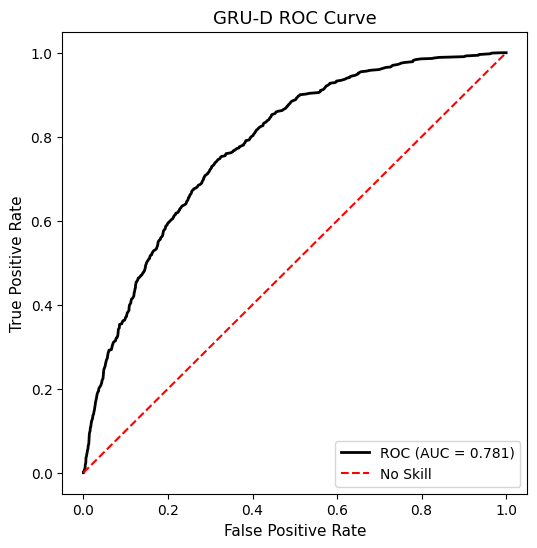

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr_c, tpr_c, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc_c = auc(fpr_c, tpr_c)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_c, y=tpr_c, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_c:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('GRU-D ROC Curve', fontsize=13)
plt.legend(loc='lower right')
plt.show()


<ipython-input-17-ee5016cea718>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby("bin")


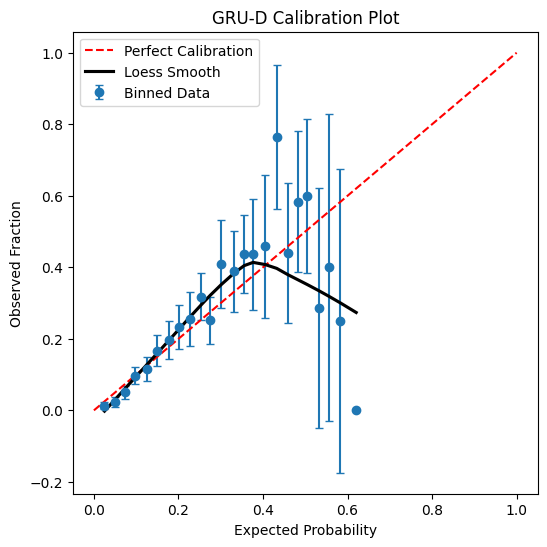

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_c = pd.DataFrame({"prob": all_test_probs, "label": all_test_labels})
num_cuts = 24

df_c["bin"] = pd.cut(df_c["prob"], bins=num_cuts, include_lowest=True)

grouped_c = (
    df_c.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)
grouped_c["se"] = np.sqrt(grouped_c["observed"] * (1 - grouped_c["observed"]) / grouped_c["n"])

plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped_c["expected"],
    y=grouped_c["observed"],
    yerr=1.96 * grouped_c["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")

sns.regplot(
    x="expected",
    y="observed",
    data=grouped_c,
    scatter=False,
    lowess=True,
    label="Loess Smooth",
    color="black"
)

plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("GRU-D Calibration Plot")
plt.legend(loc="best")
plt.show()